Mixture Density Networks

https://habr.com/ru/post/433804/

---

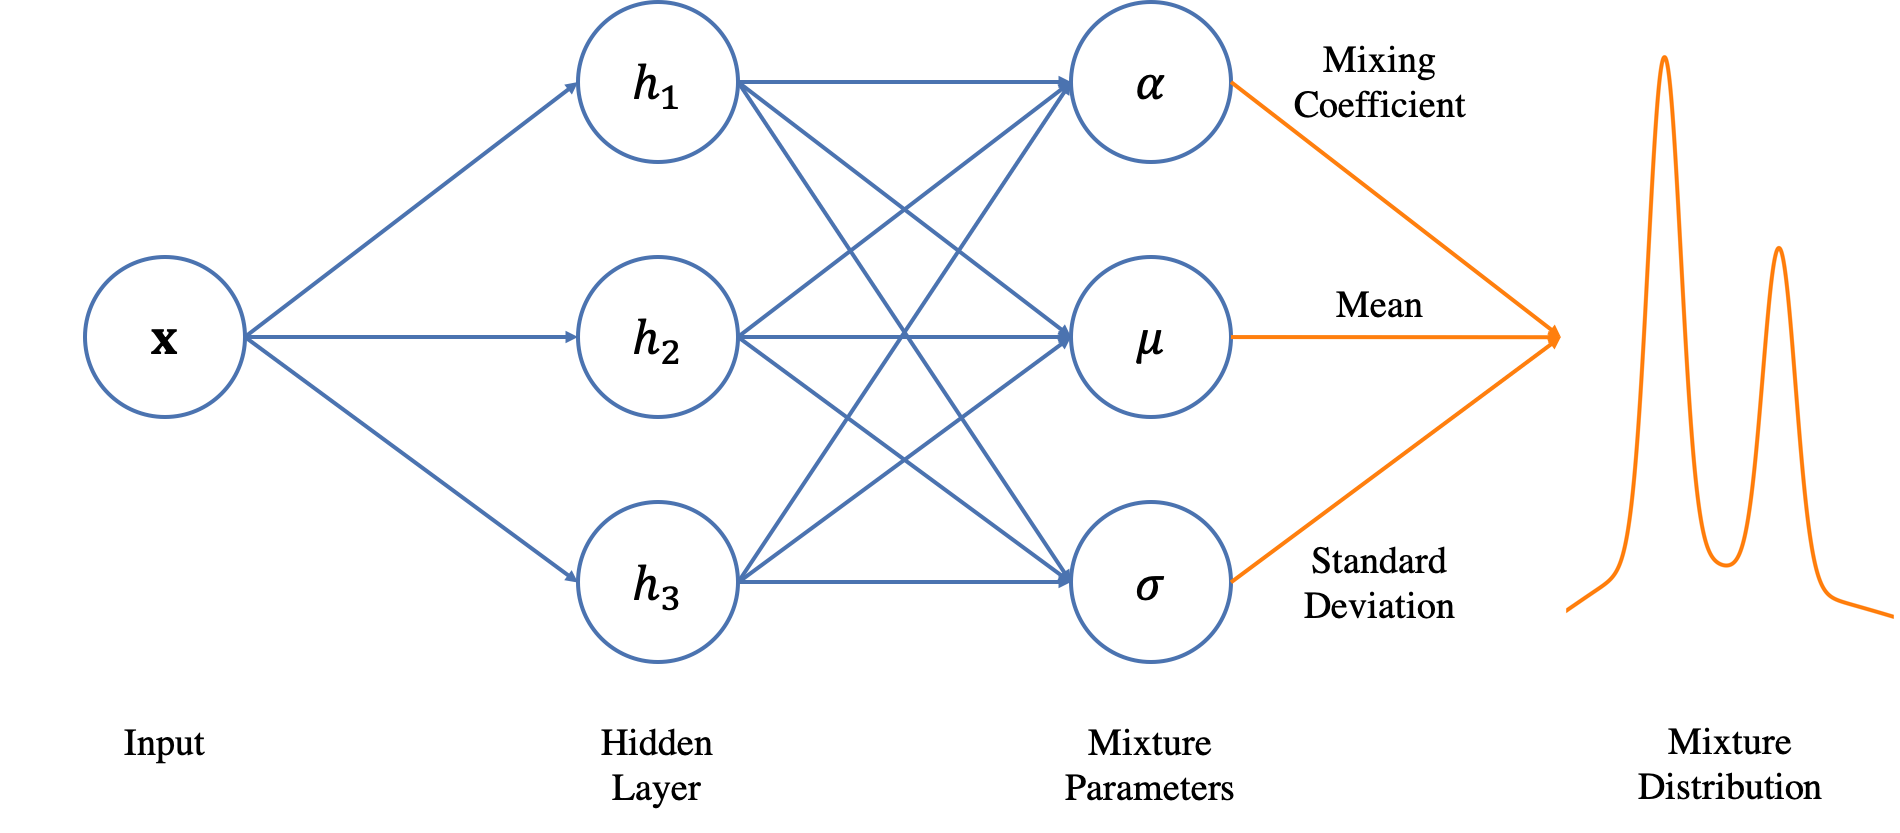

для каждой компоненты gauss-mix будем предсказывать параметры нормального распределения,   
по которым будем генерировать значения

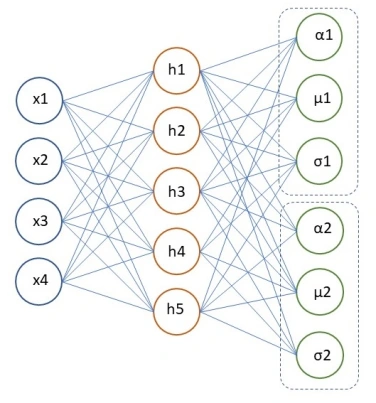

----

In [1]:
# import warnings
# warnings.filterwarnings('ignore')

In [2]:
# pip install ipywidgets 

In [3]:
# pip install scikit-learn

In [4]:
# import sys
from tqdm.cli import tqdm
import numpy as np
import numpy.random as rng
import matplotlib.pyplot as plt
# import seaborn as sns

In [5]:
plt.rcParams['figure.figsize'] = (11,5)
plt.rcParams['axes.grid'] = True
# plt.rcParams['axes.grid.axis'] = 'both'
plt.rcParams['axes.grid.which'] = 'both'
np.set_printoptions(precision=2)

# генерируем данные

In [6]:
# n_samples = 3000
# dim_in = 1

# x = rng.uniform(-4.*np.pi,+4.*np.pi,(n_samples,dim_in))
# y = 0.5*x+ 8.0*np.sin(0.3*x) + rng.normal(size=(n_samples,1))

In [7]:
# from sklearn.model_selection import train_test_split

# x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.9)
# x_train, x_val, y_train, y_val = train_test_split(x_train,y_train,train_size=0.9)

# display( (x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape ) )
# del x
# del y

In [8]:
# fig,ax = plt.subplots(figsize=(7,5))
# ax.scatter(x_train,y_train,label='train',marker='.',alpha=0.7)
# ax.scatter(x_test,y_test,label='test',marker='.',alpha=0.7)
# ax.scatter(x_val,y_val,label='val',marker='.',alpha=0.7)
# ax.legend()

----

In [9]:
n_samples = 3000
dim_in = 1

theta = np.linspace(0. , 5.*np.pi, n_samples).astype(np.float32)
x = (theta*np.cos(theta) + rng.uniform(-1,1,n_samples)).reshape(-1,1)
y = (theta*np.sin(theta)).reshape(-1,1)
del theta
display(x.shape,y.shape)

(3000, 1)

(3000, 1)

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.9)
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train,train_size=0.9)
display( (x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape ) )

del x,y

((2430, 1), (270, 1), (300, 1), (2430, 1), (270, 1), (300, 1))

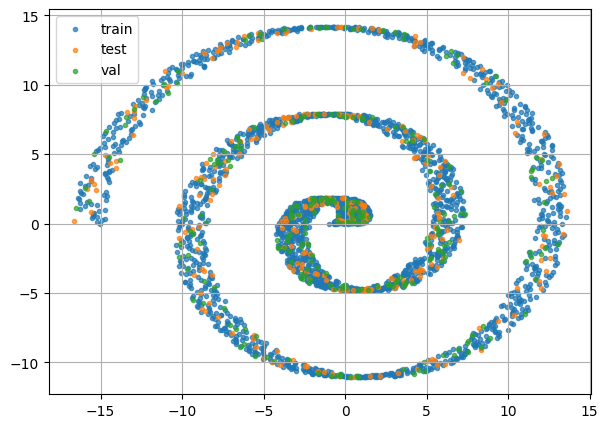

In [11]:
fig,ax = plt.subplots(figsize=(7,5))
ax.scatter(x_train,y_train,label='train',marker='.',alpha=0.7)
ax.scatter(x_test,y_test,label='test',marker='.',alpha=0.7)
ax.scatter(x_val,y_val,label='val',marker='.',alpha=0.7)
ax.legend()

# собираем датасет

In [12]:
x_train.shape, y_train.shape

((2430, 1), (2430, 1))

In [13]:
import torch

In [14]:
from torch.utils.data import TensorDataset

ds_train = TensorDataset(torch.Tensor(x_train),torch.Tensor(y_train) )
ds_val = TensorDataset(torch.Tensor(x_val),torch.Tensor(y_val) )
ds_test = TensorDataset(torch.Tensor(x_test),torch.Tensor(y_test) )

# from torch.utils.data import DataLoader
# for x,y in DataLoader(ds_train, batch_size=3, shuffle=True):
#     break
# x,y

# строим модель

In [15]:
import torch.nn as nn
import torch.nn.functional as F

$$
p(y|x,\theta) = 
\sum_k \pi_k(x,\theta) \cdot \mathcal{N}\left( y\ ;\ \mu_{k}(x,\theta),\ \sigma_{k}^2(x,\theta) \right)
$$


$$
\mathcal{N}(x|\mu,\sigma) = 
\frac{1}{\sqrt{ 2\pi\sigma } } 
\cdot \exp \left( -\frac{(x-\mu)^2}{2\sigma} \right)
$$

In [16]:
n_components = 8
# dim_in = 1
# dim_out = 1

class MDN(nn.Module):

    def __init__(self, dim_in=dim_in, n_components=n_components, hidden_size=64):
        
        super(MDN, self).__init__()
        
        # self._dim_out = dim_out
        self._n_components = n_components
        
        self._fc1 = nn.Linear(dim_in, hidden_size)
        self._fc2 = nn.Linear(hidden_size, hidden_size)
        
        self._pi = nn.Linear(hidden_size, n_components) # component weight
        self._sigm = nn.Linear(hidden_size, n_components) # variance
        self._mu = nn.Linear(hidden_size, n_components) # mean
        
    def forward(self, x):
        dim_in = x.size(1)
        o = F.relu(self._fc1(x))
        o = F.relu(self._fc2(o))
        
        pi = F.softmax(self._pi(o), dim=1) #.reshape(-1,self._n_components,1)
        sigm = torch.exp(self._sigm(o))
        mu = self._mu(o)
        
        return ( pi, mu, sigm )
    
    def predict(self,x,n_samples=1):
        pi, mu, sigm = self.forward(x)
        return D.mixture_same_family.MixtureSameFamily(
                D.Categorical(pi),
                D.Normal(mu,sigm) 
            ).sample((n_samples,)).T

In [17]:
model = MDN()

In [18]:
# model

# обучаем модель

In [19]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
model = model.to(device)
display(device)

device(type='cuda', index=1)

## собираем функцию потери с генератором значений

$$
\mathcal{N}(x|\mu,\sigma) = 
\frac{1}{\sqrt{ 2\pi\sigma } } 
\cdot \exp \left( -\frac{(x-\mu)^2}{2\sigma} \right)
$$

$$
p(y|x,\theta) = 
\sum_k \pi_k(x,\theta) \cdot \mathcal{N}\left( y\ ;\ \mu_{k}(x,\theta),\ \sigma_{k}^2(x,\theta) \right)
$$



$$
\mathcal{L}(y,\mu,\sigma,\pi) = - \frac{1}{N}\sum_{i=1}^N \log\left( p(y|\mu,\sigma,\pi) \right)
$$

In [20]:
# def gaussian_pdf(x,m,s): # probability density function (PDF)
#     return (1./torch.sqrt(2.*torch.pi*s))*torch.exp( -((x-m)**2)/(2.*s) )

# def gaussian_mix(x, mu, sigm, pi): 
#     return (pi*gaussian_pdf(x, mu, sigm)).sum(axis=1,keepdim=True)

# def loss_fn(y, mu, sigm, pi ):
#     return torch.mean(-torch.log( gaussian_mix(y,mu,sigm,pi)))

In [21]:
from torch import distributions as D

def gaussian_1D_mix(x, mu, sigm, pi): 
    return D.mixture_same_family.MixtureSameFamily(
                D.Categorical(pi),
                D.Normal(mu,sigm) 
            ).log_prob(x)

def loss_fn(y, mu, sigm, pi ):
    return torch.mean( -gaussian_1D_mix(y.T, mu, sigm, pi) )

In [22]:
criterion = loss_fn
optimizer = torch.optim.AdamW( model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=.97)

# цикл обучения

In [23]:
%%time

from torch.utils.data import DataLoader

n_epoch = 256
batch_size = 32

history_loss_train = []
history_loss_val = []
history_lr = []

for epoch in tqdm(range(n_epoch)):  
    
    history_loss = []
    for x,target in DataLoader(ds_train, batch_size=batch_size, shuffle=True):
        optimizer.zero_grad() # zero the parameter gradients
        pi, mu, sigm  = model(x.to(device))
        loss = criterion( target.to(device), pi=pi, mu=mu, sigm=sigm ) # forward 
        loss.backward() 
        optimizer.step()
        history_loss.append( loss.item() )
    history_loss_train.append( np.mean(history_loss) )
    history_lr.extend( scheduler.get_last_lr() )
    scheduler.step()
    
    history_loss = []
    with torch.no_grad(): 
        for x,target in DataLoader(ds_val, batch_size=batch_size, shuffle=True):
            pi, mu, sigm  = model(x.to(device))
            loss = criterion( target.to(device), pi=pi, mu=mu, sigm=sigm ) # forward
            history_loss.append( loss.item() )
    history_loss_val.append( np.mean(history_loss) ) 

100%|██████████| 256/256 [04:59<00:00,  1.17s/it]

CPU times: user 4min 52s, sys: 1.91 s, total: 4min 54s
Wall time: 4min 59s


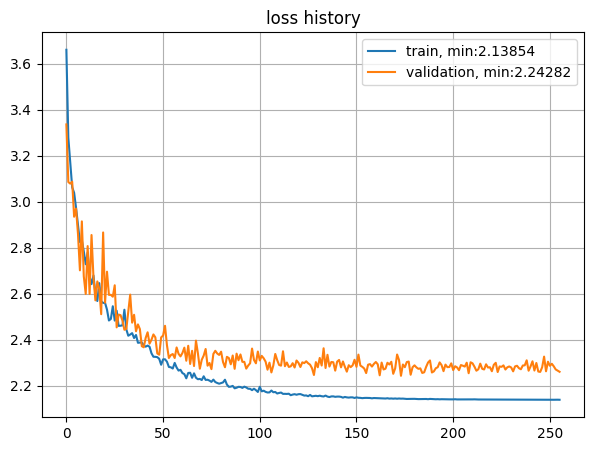

In [24]:
fig,ax = plt.subplots(figsize=(7,5))
ax.plot(history_loss_train, label=f'train, min:{min(history_loss_train):.5f}' )
ax.plot(history_loss_val, label=f'validation, min:{min(history_loss_val):.5f}' )
ax.set_title( 'loss history')
ax.legend()

# тестируем 

## предсказанные параметры смеси

In [25]:
with torch.no_grad(): 
    for x,target in DataLoader(ds_test, batch_size=len(ds_test), shuffle=False):
        pi, mu, sigm  = model(x.to(device))

ii = np.argmax( pi.cpu().numpy(),axis=1,) # номер компоненты с максимальным правдоподобием
mask = np.eye(n_components)[ii]
m = (mu.cpu().numpy()*mask).sum(axis=1,keepdims=True)
s = (sigm.cpu().numpy()*mask).sum(axis=1,keepdims=True)
x, y = x.cpu().numpy(), target.cpu().numpy()

# y_samples = rng.normal(loc=m,scale=s)

In [26]:
# y_samples

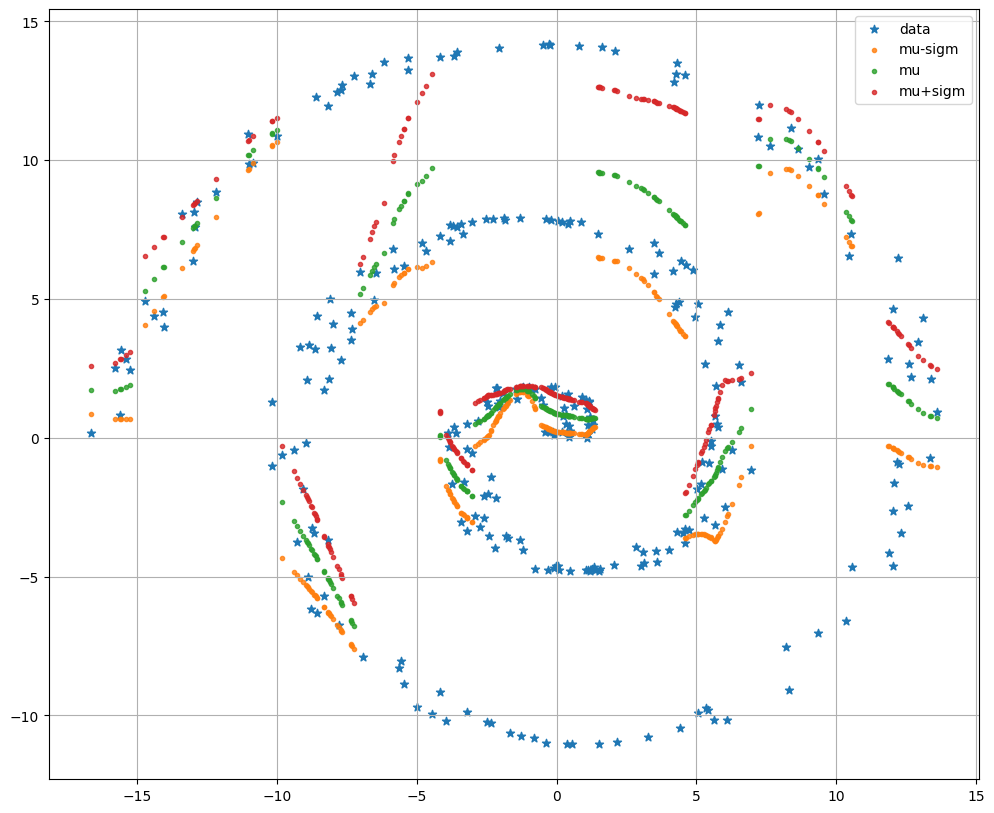

In [27]:
fig,ax = plt.subplots(figsize=(12,10))
ax.scatter(x,y,label='data',marker='*')
ax.scatter(x,m-s,label='mu-sigm',marker='.',alpha=0.8)
ax.scatter(x,m,label='mu',marker='.',alpha=0.8)
ax.scatter(x,m+s,label='mu+sigm',marker='.',alpha=0.8)
# ax.scatter(x,y_samples,label='samples',marker='.',alpha=0.8)
ax.legend()

## генерируем данные

In [28]:
with torch.no_grad(): 
    for x,target in DataLoader(ds_test, batch_size=len(ds_test), shuffle=False):
        o = model.predict(x.to(device),n_samples=1)

x, y, o = x.cpu().numpy(), target.cpu().numpy(), o.cpu().numpy()

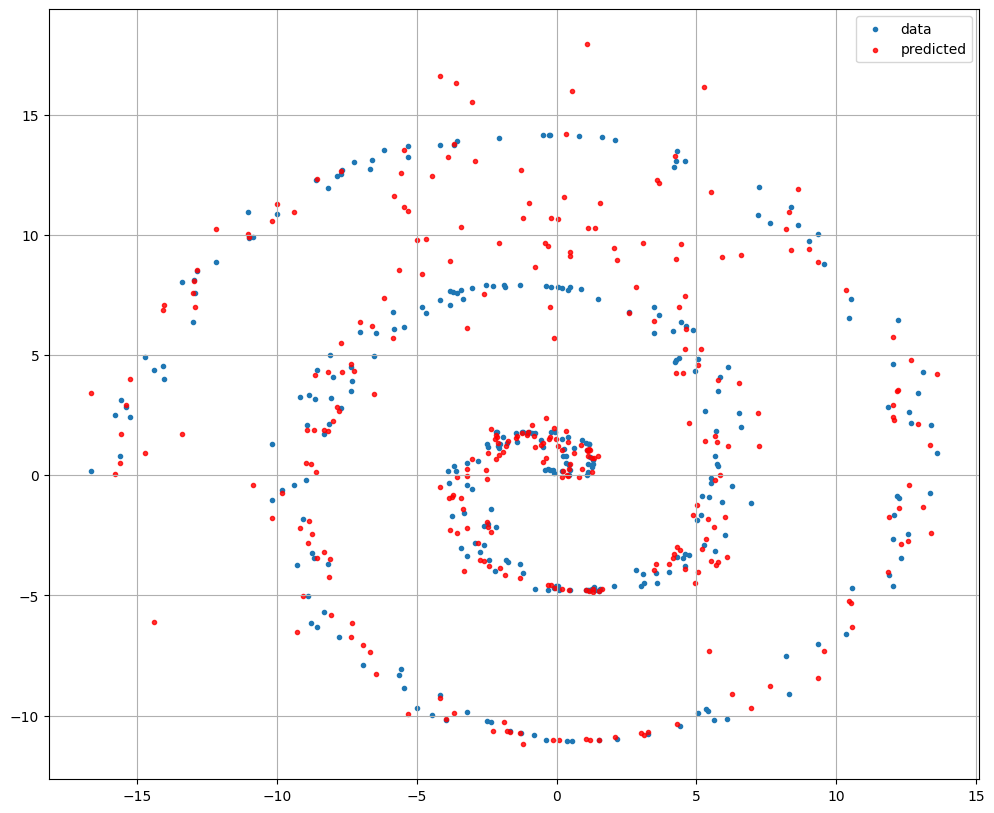

In [29]:
fig,ax = plt.subplots(figsize=(12,10))
ax.scatter(x,y,label='data',marker='.')
ax.scatter(x,o,label='predicted',marker='.',c='r',alpha=0.8)
ax.legend()

-----

In [30]:
# from torch import distributions as D

# # D.mixture_same_family.MixtureSameFamily

# # Construct Gaussian Mixture Model in 1D consisting of 5 equally
# # weighted normal distributions
# # mix = D.Categorical(torch.ones(5,))

# # mu = torch.randn(5,)
# # sigm = torch.rand(5,)
# # comp = D.Normal(mu,sigm)



# # D.mixture_same_family.MixtureSameFamily

# # Construct Gaussian Mixture Model in 1D consisting of 5 equally
# # weighted normal distributions
# # mix = D.Categorical(torch.ones(5,))

# mu = torch.randn(5,)
# sigm = torch.rand(5,)

# comp = D.Normal(mu,sigm)

# # comp.sample((5,))

# # gmm = D.mixture_same_family.MixtureSameFamily(mix, comp)

# #gmm.sample((4,))

# # mix




In [31]:
# D.mixture_same_family.MixtureSameFamily(
#                 D.Categorical(pi),
#                 D.Normal(mu,sigm) 
#             ). #.icdf(torch.Tensor(x)).shape


In [32]:
# x

In [33]:
# gmm.log_prob(x)

In [34]:
# torch.Tensor(x).shape

In [35]:
# n_samples, n_components  = 5, 3
# pi   = torch.rand(n_samples,n_components)
# mu   = torch.rand(n_samples,n_components)
# sigm = torch.rand(n_samples,n_components)
# x = torch.rand(n_samples,1)
# display(( pi.shape, mu.shape, sigm.shape, x.shape ))
# display( gaussian_pdf(x, mu, sigm).shape )
# display( gaussian_mix(x, mu, sigm, pi).shape )